<a href="https://colab.research.google.com/github/SriSharanya-617/PCA/blob/main/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [3]:
# Load dataset
iris = load_iris()


In [4]:
X = iris.data
y = iris.target

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X.shape

(150, 4)

apply pca and visual screen plot

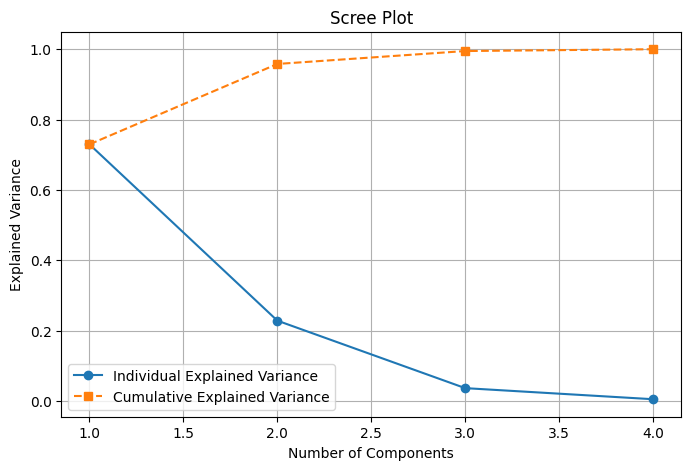

In [9]:


# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Scree Plot
plt.figure(figsize=(8,5))

# Individual explained variance
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    'o-',
    label="Individual Explained Variance"
)

# Cumulative explained variance
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    's--',
    label="Cumulative Explained Variance"
)

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
pca_95 = PCA(n_components=0.95)

X_reduced = pca_95.fit_transform(X_scaled)

print("Reduced Shape:", X_reduced.shape)

Reduced Shape: (150, 2)


visualize top 2 componenets

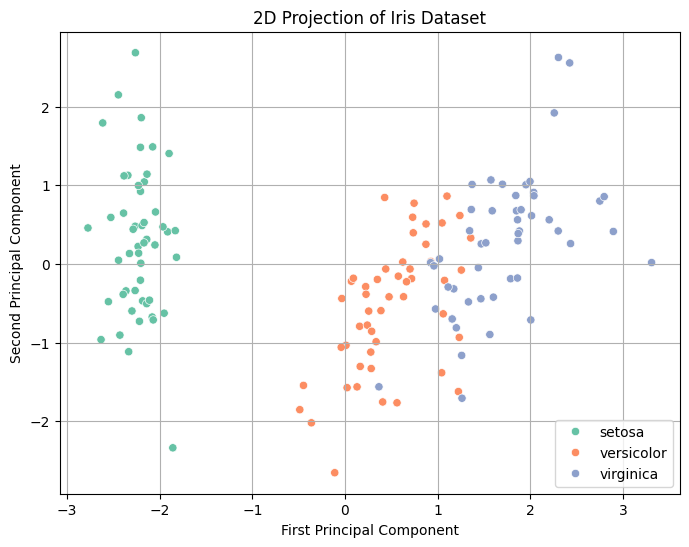

In [11]:
pca_2d=PCA(n_components=2)
X_2d=pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0],y=X_2d[:,1],hue=iris.target_names[y],palette='Set2')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D Projection of Iris Dataset')
plt.grid(True)
plt.show()

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive')

# Path to the dataset (update if needed)
path = '/content/drive/My Drive/marketing_campaign.csv'

# Importing the dataset
df= pd.read_csv(path)
print(df.head())



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
0  5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...                                                                                                                                                                                                                                                                                                                                                  
1  2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...                                     

In [18]:
df = pd.read_csv(path, delimiter="\t", engine="python")
print(df.columns)
print("Prepared shape:", X_scaled.shape)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')
Prepared shape: (150, 4)


In [19]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


In [20]:
num_cols = [
    'Income','Recency','MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds',
    'NumDealsPurchases','NumWebPurchases','NumCatalogPurchases',
    'NumStorePurchases','NumWebVisitsMonth'
]

data = df[num_cols].copy()
print(data.head())

    Income  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  58138.0       58       635         88              546              172   
1  46344.0       38        11          1                6                2   
2  71613.0       26       426         49              127              111   
3  26646.0       26        11          4               20               10   
4  58293.0       94       173         43              118               46   

   MntSweetProducts  MntGoldProds  NumDealsPurchases  NumWebPurchases  \
0                88            88                  3                8   
1                 1             6                  2                1   
2                21            42                  1                8   
3                 3             5                  2                2   
4                27            15                  5                5   

   NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  
0                   10       

In [21]:
from sklearn.preprocessing import StandardScaler

data = data.fillna(data.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (2240, 13)


In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA on scaled data
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

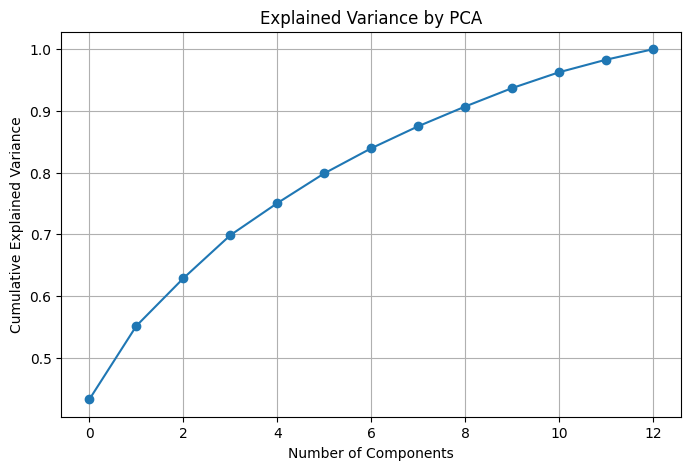

In [23]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA")
plt.grid(True)
plt.show()

In [24]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1

print("Components needed for 90% variance:", n_components_90)

Components needed for 90% variance: 9


In [25]:
pca_final = PCA(n_components=n_components_90)
X_reduced = pca_final.fit_transform(X_scaled)

print("Reduced dataset shape:", X_reduced.shape)

Reduced dataset shape: (2240, 9)


In [26]:
import pandas as pd

loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components_90)],
    index=data.columns
)

print("Top features in PC1")
print(loadings["PC1"].sort_values(ascending=False).head())

print("\nTop features in PC2")
print(loadings["PC2"].sort_values(ascending=False).head())

Top features in PC1
NumCatalogPurchases    0.344484
MntMeatProducts        0.338476
Income                 0.316262
MntWines               0.315725
NumStorePurchases      0.314039
Name: PC1, dtype: float64

Top features in PC2
NumDealsPurchases    0.635197
NumWebPurchases      0.495957
NumWebVisitsMonth    0.407355
MntWines             0.223503
MntGoldProds         0.195424
Name: PC2, dtype: float64


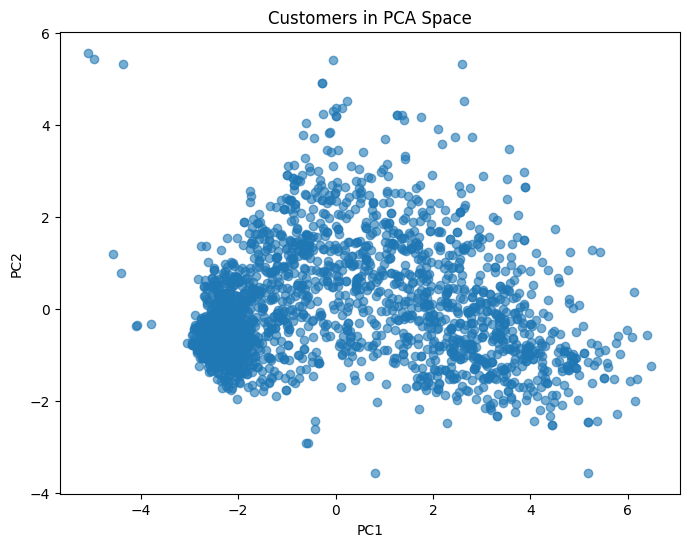

In [27]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in PCA Space")
plt.show()

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

start = time.time()

kmeans_orig = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X_scaled)

time_orig = time.time() - start
sil_orig = silhouette_score(X_scaled, labels_orig)

print("Silhouette (original):", sil_orig)
print("Time (original):", time_orig)

Silhouette (original): 0.25978922589037345
Time (original): 0.23209834098815918


In [29]:
start = time.time()

kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_reduced)

time_pca = time.time() - start
sil_pca = silhouette_score(X_reduced, labels_pca)

print("Silhouette (PCA):", sil_pca)
print("Time (PCA):", time_pca)

Silhouette (PCA): 0.28355828128292315
Time (PCA): 0.0495448112487793


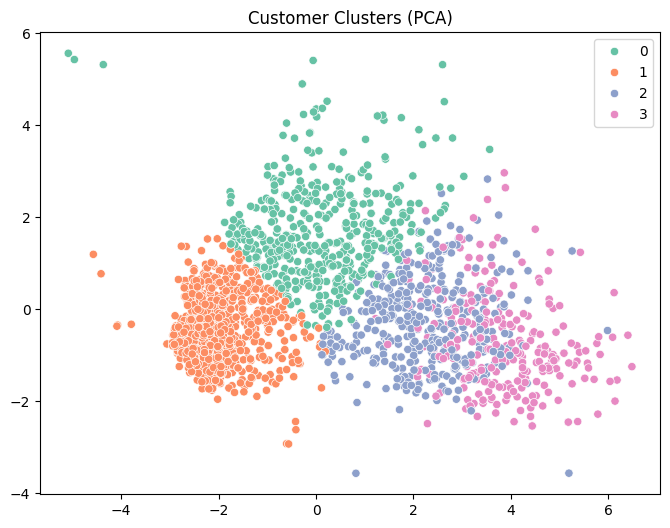

In [30]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=labels_pca, palette="Set2")
plt.title("Customer Clusters (PCA)")
plt.show()

In [31]:
print("=== FINAL COMPARISON ===")
print("Original Silhouette:", sil_orig)
print("PCA Silhouette:", sil_pca)
print("Original Time:", time_orig)
print("PCA Time:", time_pca)

=== FINAL COMPARISON ===
Original Silhouette: 0.25978922589037345
PCA Silhouette: 0.28355828128292315
Original Time: 0.23209834098815918
PCA Time: 0.0495448112487793
